## EDA Bunty

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# NLP Libraries
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter
import re

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [21]:
# Load the dataset
df = pd.read_csv('../youtoxic_english_1000.csv')

print(f"Dataset shape: {df.shape}")
print(f"Total comments: {len(df)}")
print("\n" + "="*50)

Dataset shape: (1000, 15)
Total comments: 1000



In [22]:
# Display first rows
print("📊 First 5 rows of the dataset:")
display(df.head())

📊 First 5 rows of the dataset:


,CommentId,VideoId,Text,IsToxic,IsAbusive,IsThreat,IsProvocative,IsObscene,IsHatespeech,IsRacist,IsNationalist,IsSexist,IsHomophobic,IsReligiousHate,IsRadicalism
0,Ugg2KwwX0V8-aXgCoAEC,04kJtp6pVXI,"If only people would just take a step back and not make this case about them, because it wasn't ...",False,False,False,False,False,False,False,False,False,False,False,False
1,Ugg2s5AzSPioEXgCoAEC,04kJtp6pVXI,Law enforcement is not trained to shoot to apprehend. They are trained to shoot to kill. And I...,True,True,False,False,False,False,False,False,False,False,False,False
2,Ugg3dWTOxryFfHgCoAEC,04kJtp6pVXI,\nDont you reckon them 'black lives matter' banners being held by white cunts is kinda patroniz...,True,True,False,False,True,False,False,False,False,False,False,False
3,Ugg7Gd006w1MPngCoAEC,04kJtp6pVXI,There are a very large number of people who do not like police officers. They are called Crimina...,False,False,False,False,False,False,False,False,False,False,False,False
4,Ugg8FfTbbNF8IngCoAEC,04kJtp6pVXI,"The Arab dude is absolutely right, he should have not been shot 6 extra time. Shoot him once if ...",False,False,False,False,False,False,False,False,False,False,False,False


In [23]:
# Dataset info
print("\n📋 Dataset Information:")
df.info()


📋 Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   CommentId        1000 non-null   object
 1   VideoId          1000 non-null   object
 2   Text             1000 non-null   object
 3   IsToxic          1000 non-null   bool  
 4   IsAbusive        1000 non-null   bool  
 5   IsThreat         1000 non-null   bool  
 6   IsProvocative    1000 non-null   bool  
 7   IsObscene        1000 non-null   bool  
 8   IsHatespeech     1000 non-null   bool  
 9   IsRacist         1000 non-null   bool  
 10  IsNationalist    1000 non-null   bool  
 11  IsSexist         1000 non-null   bool  
 12  IsHomophobic     1000 non-null   bool  
 13  IsReligiousHate  1000 non-null   bool  
 14  IsRadicalism     1000 non-null   bool  
dtypes: bool(12), object(3)
memory usage: 35.3+ KB


In [24]:
# Basic statistics
print("\n📈 Basic Statistics:")
display(df.describe())


📈 Basic Statistics:


,CommentId,VideoId,Text,IsToxic,IsAbusive,IsThreat,IsProvocative,IsObscene,IsHatespeech,IsRacist,IsNationalist,IsSexist,IsHomophobic,IsReligiousHate,IsRadicalism
count,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000
unique,1000,13,997,2,2,2,2,2,2,2,2,2,1,2,1
top,Ugg2KwwX0V8-aXgCoAEC,9pr1oE34bIM,run them over,False,False,False,False,False,False,False,False,False,False,False,False
freq,1,274,3,538,647,979,839,900,862,875,992,999,1000,988,1000


In [25]:
# Check for missing values
print("\n🔍 Missing Values:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "No missing values found!")



🔍 Missing Values:
No missing values found!


In [26]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"\n🔄 Duplicate rows: {duplicates}")


🔄 Duplicate rows: 0


In [27]:
# List of toxicity labels
toxicity_labels = [
    'IsToxic', 'IsAbusive', 'IsThreat', 'IsProvocative', 
    'IsObscene', 'IsHatespeech', 'IsRacist', 'IsNationalist', 
    'IsSexist', 'IsHomophobic', 'IsReligiousHate', 'IsRadicalism'
]

# Count of toxic comments per category
print("\n🎯 Toxicity Distribution:")
toxicity_counts = df[toxicity_labels].sum().sort_values(ascending=False)
print(toxicity_counts)


🎯 Toxicity Distribution:
IsToxic            462
IsAbusive          353
IsProvocative      161
IsHatespeech       138
IsRacist           125
IsObscene          100
IsThreat            21
IsReligiousHate     12
IsNationalist        8
IsSexist             1
IsHomophobic         0
IsRadicalism         0
dtype: int64


In [28]:
# Calculate percentages
print("\n📊 Toxicity Percentages:")
toxicity_percentages = (df[toxicity_labels].sum() / len(df) * 100).sort_values(ascending=False)
for label, percentage in toxicity_percentages.items():
    print(f"{label}: {percentage:.2f}%")


📊 Toxicity Percentages:
IsToxic: 46.20%
IsAbusive: 35.30%
IsProvocative: 16.10%
IsHatespeech: 13.80%
IsRacist: 12.50%
IsObscene: 10.00%
IsThreat: 2.10%
IsReligiousHate: 1.20%
IsNationalist: 0.80%
IsSexist: 0.10%
IsHomophobic: 0.00%
IsRadicalism: 0.00%


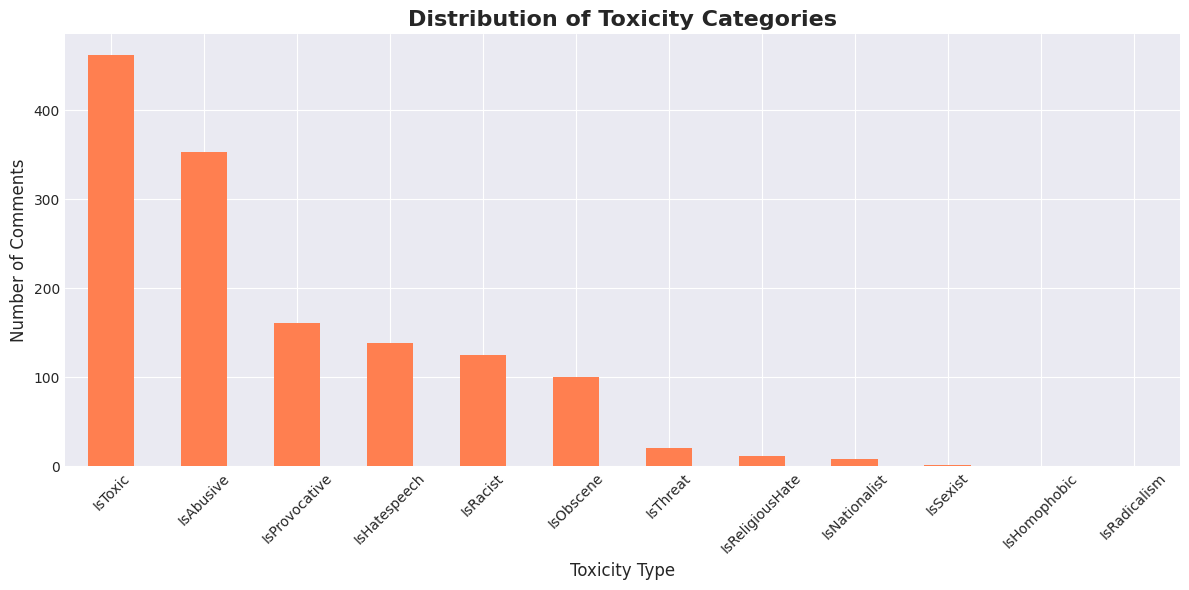

In [29]:
# Visualize toxicity distribution
fig, ax = plt.subplots(figsize=(12, 6))
toxicity_counts.plot(kind='bar', ax=ax, color='coral')
ax.set_title('Distribution of Toxicity Categories', fontsize=16, fontweight='bold')
ax.set_xlabel('Toxicity Type', fontsize=12)
ax.set_ylabel('Number of Comments', fontsize=12)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [30]:
# Check overall toxicity (at least one toxic label = True)
df['is_any_toxic'] = df[toxicity_labels].any(axis=1)
toxic_count = df['is_any_toxic'].sum()
non_toxic_count = len(df) - toxic_count

print(f"\n⚖️ Overall Class Distribution:")
print(f"Toxic comments: {toxic_count} ({toxic_count/len(df)*100:.2f}%)")
print(f"Non-toxic comments: {non_toxic_count} ({non_toxic_count/len(df)*100:.2f}%)")


⚖️ Overall Class Distribution:
Toxic comments: 462 (46.20%)
Non-toxic comments: 538 (53.80%)


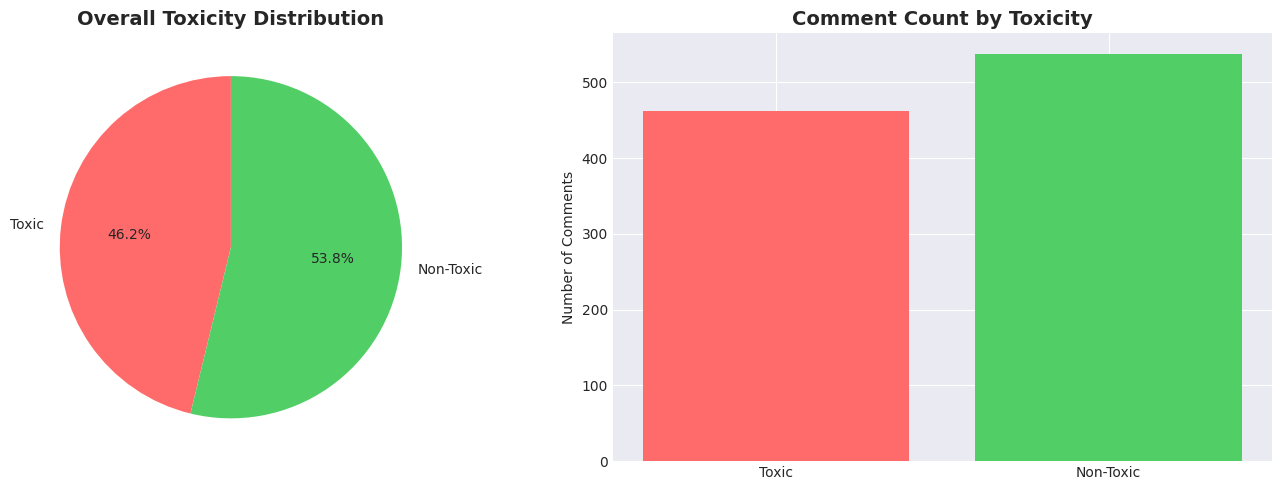

In [31]:
# Visualize class balance
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
ax[0].pie([toxic_count, non_toxic_count], 
          labels=['Toxic', 'Non-Toxic'],
          autopct='%1.1f%%',
          startangle=90,
          colors=['#ff6b6b', '#51cf66'])
ax[0].set_title('Overall Toxicity Distribution', fontsize=14, fontweight='bold')

# Bar chart
ax[1].bar(['Toxic', 'Non-Toxic'], [toxic_count, non_toxic_count], color=['#ff6b6b', '#51cf66'])
ax[1].set_title('Comment Count by Toxicity', fontsize=14, fontweight='bold')
ax[1].set_ylabel('Number of Comments')

plt.tight_layout()
plt.show()


📏 Text Length Statistics:
Average text length: 185.55 characters
Average word count: 33.78 words
Max text length: 4421 characters
Min text length: 3 characters

📊 Text Length by Toxicity:
             text_length                                                     \
                   count        mean         std  min    25%    50%     75%   
is_any_toxic                                                                  
False              538.0  182.262082  252.295702  3.0  44.00   96.0  210.75   
True               462.0  189.387446  291.061941  6.0  54.25  110.0  220.75   

                     word_count                                               \
                 max      count       mean        std  min   25%   50%   75%   
is_any_toxic                                                                   
False         2292.0      538.0  33.065056  45.165137  1.0   8.0  18.0  38.0   
True          4421.0      462.0  34.603896  53.294876  1.0  10.0  20.0  40.0   

              

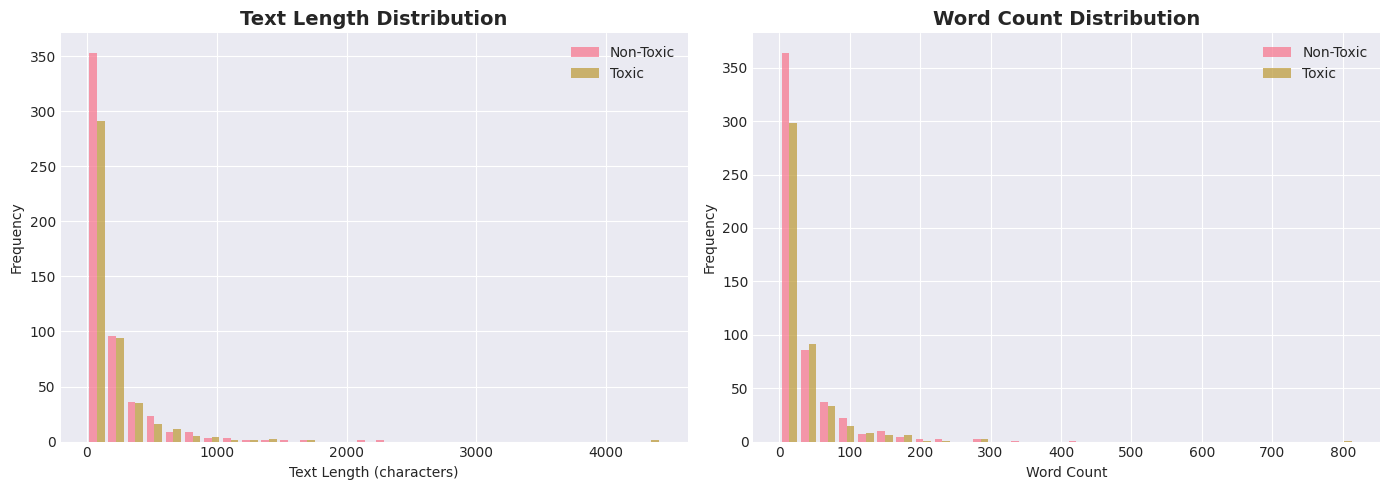

In [32]:
# %%
# Calculate text length
df['text_length'] = df['Text'].str.len()
df['word_count'] = df['Text'].str.split().str.len()

print("\n📏 Text Length Statistics:")
print(f"Average text length: {df['text_length'].mean():.2f} characters")
print(f"Average word count: {df['word_count'].mean():.2f} words")
print(f"Max text length: {df['text_length'].max()} characters")
print(f"Min text length: {df['text_length'].min()} characters")

# %%
# Compare text length between toxic and non-toxic
print("\n📊 Text Length by Toxicity:")
print(df.groupby('is_any_toxic')[['text_length', 'word_count']].describe())

# %%
# Visualize text length distribution
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Text length distribution
ax[0].hist([df[df['is_any_toxic']==False]['text_length'], 
            df[df['is_any_toxic']==True]['text_length']], 
           bins=30, label=['Non-Toxic', 'Toxic'], alpha=0.7)
ax[0].set_xlabel('Text Length (characters)')
ax[0].set_ylabel('Frequency')
ax[0].set_title('Text Length Distribution', fontsize=14, fontweight='bold')
ax[0].legend()

# Word count distribution
ax[1].hist([df[df['is_any_toxic']==False]['word_count'], 
            df[df['is_any_toxic']==True]['word_count']], 
           bins=30, label=['Non-Toxic', 'Toxic'], alpha=0.7)
ax[1].set_xlabel('Word Count')
ax[1].set_ylabel('Frequency')
ax[1].set_title('Word Count Distribution', fontsize=14, fontweight='bold')
ax[1].legend()

plt.tight_layout()
plt.show()

# ## 7. Multi-Label Analysis


🏷️ Multi-Label Distribution:
num_toxic_labels
0    538
2    100
3    294
4     47
5     15
6      6
Name: count, dtype: int64


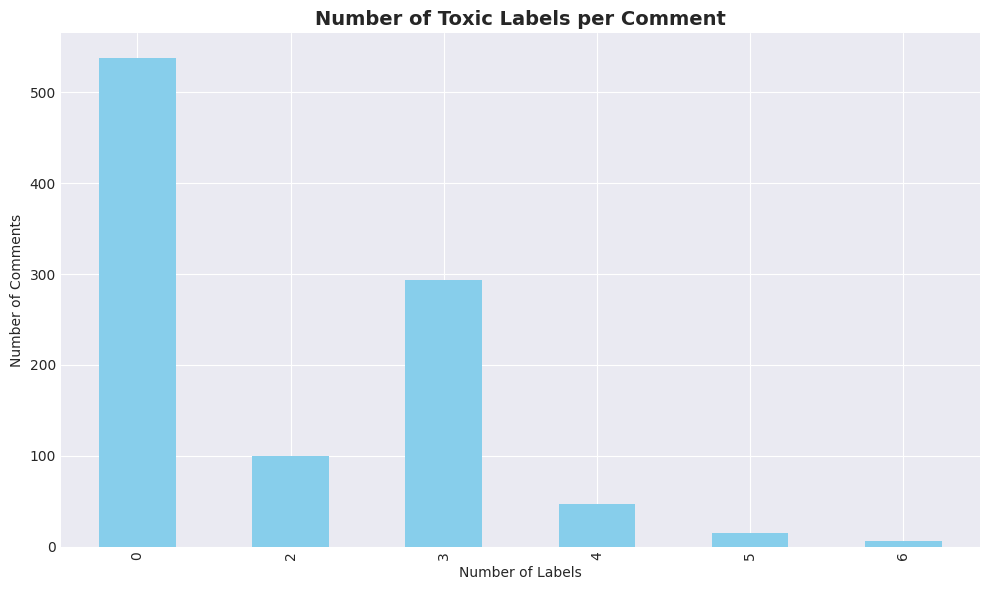


🔗 Correlation Matrix of Toxicity Labels:


,IsToxic,IsAbusive,IsThreat,IsProvocative,IsObscene,IsHatespeech,IsRacist,IsNationalist,IsSexist,IsHomophobic,IsReligiousHate,IsRadicalism
IsToxic,1.000000,0.797086,0.158048,0.472718,0.359707,0.431774,0.407869,0.096908,0.034142,NaN,0.118928,NaN
IsAbusive,0.797086,1.000000,0.198282,0.593057,0.451277,-0.119603,-0.121005,-0.042843,0.042833,NaN,-0.042970,NaN
IsThreat,0.158048,0.198282,1.000000,0.106626,-0.048820,0.002063,-0.034268,-0.013152,-0.004634,NaN,0.111962,NaN
IsProvocative,0.472718,0.593057,0.106626,1.000000,0.089788,-0.072719,-0.075072,-0.008796,-0.013860,NaN,0.001699,NaN
IsObscene,0.359707,0.451277,-0.048820,0.089788,1.000000,-0.027061,-0.035277,-0.029934,0.094916,NaN,-0.036736,NaN
IsHatespeech,0.431774,-0.119603,0.002063,-0.072719,-0.027061,1.000000,0.944637,0.224442,0.079074,NaN,0.275440,NaN
IsRacist,0.407869,-0.121005,-0.034268,-0.075072,-0.035277,0.944637,1.000000,0.237595,-0.011958,NaN,0.013885,NaN
IsNationalist,0.096908,-0.042843,-0.013152,-0.008796,-0.029934,0.224442,0.237595,1.000000,-0.002841,NaN,-0.009897,NaN
IsSexist,0.034142,0.042833,-0.004634,-0.013860,0.094916,0.079074,-0.011958,-0.002841,1.000000,NaN,-0.003487,NaN
IsHomophobic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


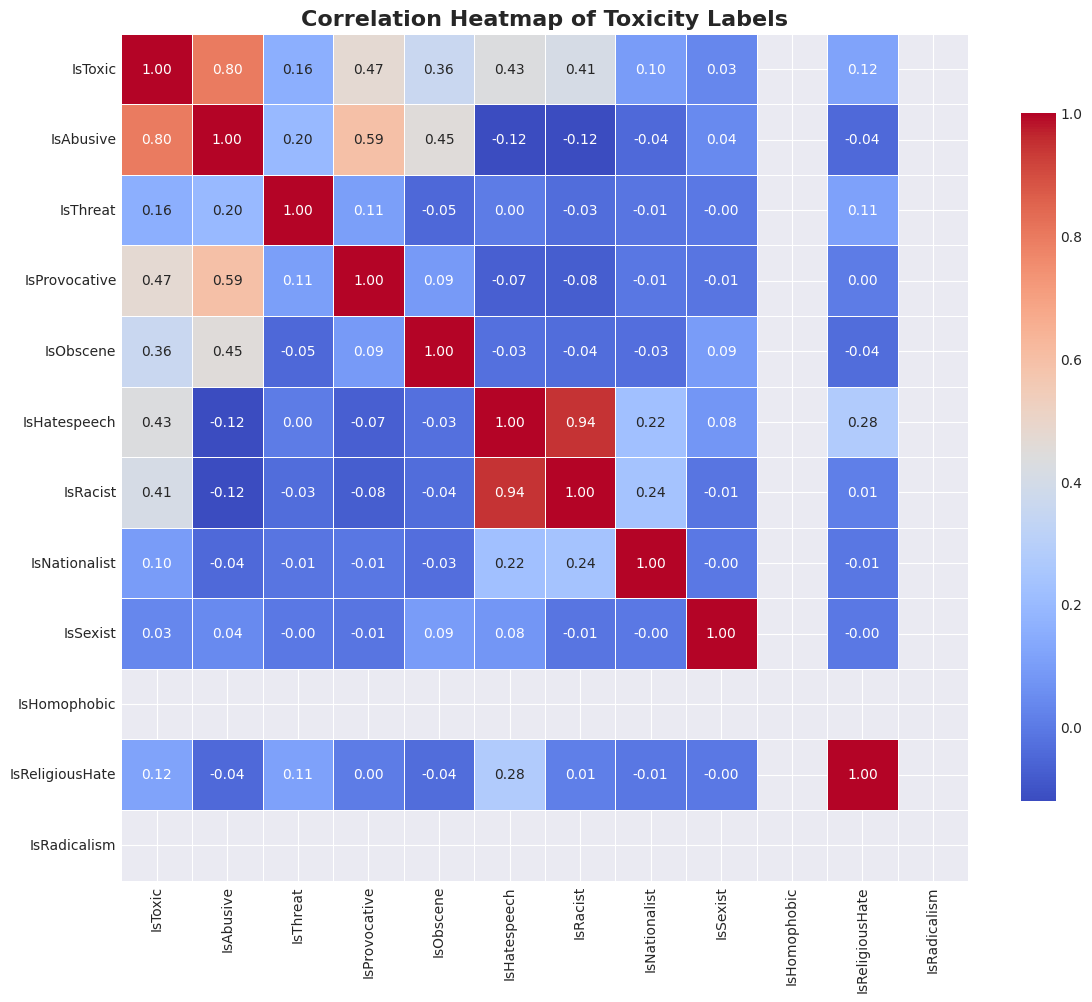

In [33]:
# %%
# Count how many labels each comment has
df['num_toxic_labels'] = df[toxicity_labels].sum(axis=1)

print("\n🏷️ Multi-Label Distribution:")
print(df['num_toxic_labels'].value_counts().sort_index())

# %%
# Visualize multi-label distribution
fig, ax = plt.subplots(figsize=(10, 6))
df['num_toxic_labels'].value_counts().sort_index().plot(kind='bar', ax=ax, color='skyblue')
ax.set_title('Number of Toxic Labels per Comment', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Labels')
ax.set_ylabel('Number of Comments')
plt.tight_layout()
plt.show()

# %%
# Correlation between toxicity labels
print("\n🔗 Correlation Matrix of Toxicity Labels:")
correlation_matrix = df[toxicity_labels].corr()
display(correlation_matrix)

# %%
# Visualize correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap of Toxicity Labels', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Sample Comments Analysis

In [34]:
# Display sample toxic comments
print("\n💬 Sample Toxic Comments:")
print("="*80)
toxic_samples = df[df['is_any_toxic']==True].head(5)
for idx, row in toxic_samples.iterrows():
    labels = [label for label in toxicity_labels if row[label]]
    print(f"\nComment: {row['Text'][:200]}...")
    print(f"Labels: {', '.join(labels)}")
    print("-"*80)

# %%
# Display sample non-toxic comments
print("\n✅ Sample Non-Toxic Comments:")
print("="*80)
non_toxic_samples = df[df['is_any_toxic']==False].head(5)
for idx, row in non_toxic_samples.iterrows():
    print(f"\nComment: {row['Text'][:200]}...")
    print("-"*80)



💬 Sample Toxic Comments:

Comment: Law enforcement is not trained to shoot to apprehend.  They are trained to shoot to kill.  And I thank Wilson for killing that punk bitch....
Labels: IsToxic, IsAbusive
--------------------------------------------------------------------------------

Comment: 
Dont you reckon them 'black lives matter' banners being held by white cunts is  kinda patronizing and ironically racist. could they have not come up with somethin better.. or is it just what white fo...
Labels: IsToxic, IsAbusive, IsObscene
--------------------------------------------------------------------------------

Comment: here people his facebook is https://www.facebook.com/bassem.masri.520 he has ties with isis and other terrorist groups he is a muslim extremist ...
Labels: IsToxic, IsHatespeech, IsReligiousHate
--------------------------------------------------------------------------------

Comment: Check out this you tube post. "Black man goes on an epic rant against Ferguson rioter

## 9. Initial Text Preprocessing Exploration

In [35]:
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')
    nltk.download('punkt')

# %%
def basic_text_stats(text):
    """Calculate basic text statistics"""
    # Count special characters
    special_chars = len(re.findall(r'[!@#$%^&*()_+\-=\[\]{};:\'",.<>?/\\|`~]', text))
    # Count uppercase words
    uppercase_words = len(re.findall(r'\b[A-Z]{2,}\b', text))
    # Count numbers
    numbers = len(re.findall(r'\d+', text))
    # Count URLs
    urls = len(re.findall(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', text))
    
    return special_chars, uppercase_words, numbers, urls

# Apply stats
df['special_chars'] = df['Text'].apply(lambda x: basic_text_stats(x)[0])
df['uppercase_words'] = df['Text'].apply(lambda x: basic_text_stats(x)[1])
df['numbers'] = df['Text'].apply(lambda x: basic_text_stats(x)[2])
df['urls'] = df['Text'].apply(lambda x: basic_text_stats(x)[3])

print("\n🔤 Text Characteristics by Toxicity:")
print(df.groupby('is_any_toxic')[['special_chars', 'uppercase_words', 'numbers', 'urls']].mean())



🔤 Text Characteristics by Toxicity:
              special_chars  uppercase_words   numbers      urls
is_any_toxic                                                    
False              5.868030         0.522305  0.384758  0.020446
True               5.792208         1.099567  0.296537  0.002165


## 10. Key Findings Summary

In [36]:
print("\n" + "="*80)
print("📋 KEY FINDINGS SUMMARY")
print("="*80)

print(f"\n1. Dataset Overview:")
print(f"   - Total comments: {len(df)}")
print(f"   - Toxic comments: {toxic_count} ({toxic_count/len(df)*100:.2f}%)")
print(f"   - Non-toxic comments: {non_toxic_count} ({non_toxic_count/len(df)*100:.2f}%)")

print(f"\n2. Most Common Toxicity Types:")
for i, (label, count) in enumerate(toxicity_counts.head(3).items(), 1):
    print(f"   {i}. {label}: {count} comments ({count/len(df)*100:.2f}%)")

print(f"\n3. Text Characteristics:")
print(f"   - Average text length: {df['text_length'].mean():.2f} characters")
print(f"   - Average word count: {df['word_count'].mean():.2f} words")

print(f"\n4. Multi-Label Insights:")
print(f"   - Comments with multiple labels: {(df['num_toxic_labels'] > 1).sum()}")
print(f"   - Max labels per comment: {df['num_toxic_labels'].max()}")

print(f"\n5. Class Imbalance:")
imbalance_ratio = max(toxic_count, non_toxic_count) / min(toxic_count, non_toxic_count)
print(f"   - Imbalance ratio: {imbalance_ratio:.2f}:1")
print(f"   - Action needed: {'Yes - Consider SMOTE or class weights' if imbalance_ratio > 1.5 else 'No - Relatively balanced'}")

print("\n" + "="*80)


📋 KEY FINDINGS SUMMARY

1. Dataset Overview:
   - Total comments: 1000
   - Toxic comments: 462 (46.20%)
   - Non-toxic comments: 538 (53.80%)

2. Most Common Toxicity Types:
   1. IsToxic: 462 comments (46.20%)
   2. IsAbusive: 353 comments (35.30%)
   3. IsProvocative: 161 comments (16.10%)

3. Text Characteristics:
   - Average text length: 185.55 characters
   - Average word count: 33.78 words

4. Multi-Label Insights:
   - Comments with multiple labels: 462
   - Max labels per comment: 6

5. Class Imbalance:
   - Imbalance ratio: 1.16:1
   - Action needed: No - Relatively balanced



## 11. Next Steps

In [37]:
print("\n📝 RECOMMENDED NEXT STEPS:")
print("-" * 80)
print("1. Text Preprocessing:")
print("   - Lowercase conversion")
print("   - Remove special characters, URLs, numbers")
print("   - Remove stopwords")
print("   - Lemmatization/Stemming")
print("   - Handle contractions")
print("\n2. Feature Engineering:")
print("   - TF-IDF vectorization")
print("   - Word embeddings (Word2Vec, GloVe)")
print("   - N-grams analysis")
print("\n3. Model Selection:")
print("   - Start with classical ML (Naive Bayes, Logistic Regression, SVM)")
print("   - Progress to ensemble methods (Random Forest, XGBoost)")
print("   - Implement neural networks (LSTM, BiLSTM)")
print("   - Finally, use Transformers (BERT, RoBERTa)")
print("\n4. Handle Class Imbalance:")
print("   - Use SMOTE for oversampling minority class")
print("   - Apply class weights in models")
print("   - Consider focal loss for neural networks")
print("-" * 80)


📝 RECOMMENDED NEXT STEPS:
--------------------------------------------------------------------------------
1. Text Preprocessing:
   - Lowercase conversion
   - Remove special characters, URLs, numbers
   - Remove stopwords
   - Lemmatization/Stemming
   - Handle contractions

2. Feature Engineering:
   - TF-IDF vectorization
   - Word embeddings (Word2Vec, GloVe)
   - N-grams analysis

3. Model Selection:
   - Start with classical ML (Naive Bayes, Logistic Regression, SVM)
   - Progress to ensemble methods (Random Forest, XGBoost)
   - Implement neural networks (LSTM, BiLSTM)
   - Finally, use Transformers (BERT, RoBERTa)

4. Handle Class Imbalance:
   - Use SMOTE for oversampling minority class
   - Apply class weights in models
   - Consider focal loss for neural networks
--------------------------------------------------------------------------------
